In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split,  cross_val_score
from sklearn.metrics import classification_report, accuracy_score
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report




In [32]:
from sklearn.model_selection import learning_curve

In [33]:
import matplotlib.pyplot as plt

In [34]:
from imblearn.combine import SMOTEENN

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('cardio_train.csv', sep=';')
df['age'] = df['age']/ 365

df['bmi'] = df['weight'] / ((df['height']/100)**2)
df = df[(df['bmi'] >= 15) & (df['bmi'] <= 50)]

df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)
df['obesity'] = (df['bmi'] >= 30).astype(int)

X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if X[col].nunique() > 10]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

X_train_rest = X_train.drop(columns=numeric_cols).reset_index(drop=True)
X_test_rest = X_test.drop(columns=numeric_cols).reset_index(drop=True)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numeric_cols).reset_index(drop=True)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numeric_cols).reset_index(drop=True)

X_train_final = pd.concat([X_train_scaled_df, X_train_rest], axis=1)
X_test_final = pd.concat([X_test_scaled_df, X_test_rest], axis=1)



In [36]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,pulse_pressure,hypertension,obesity
0,0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0,21.967120,30,0,0
1,1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1,34.927679,50,1,1
2,2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1,23.507805,60,0,0
3,3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1,28.710479,50,1,0
4,4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0,23.011177,40,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69994,99992,57.736986,1,165,80.0,150,80,1,1,0,0,1,1,29.384757,70,1,0
69995,99993,52.712329,2,168,76.0,120,80,1,1,1,0,1,0,26.927438,40,0,0
69997,99996,52.235616,2,183,105.0,180,90,3,1,0,1,0,1,31.353579,90,1,1
69998,99998,61.454795,1,163,72.0,135,80,1,2,0,0,0,1,27.099251,55,0,0


# Random Forest

In [39]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=13,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    oob_score=False ,
    bootstrap=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


In [40]:
feature_names = [
    "id", "age", "gender", "height", "weight", "ap_hi", "ap_lo",
    "cholesterol", "gluc", "smoke", "alco", "active", "cardio",
    "bmi", "pulse_pressure", "hypertension", "obesity"
]


In [41]:
X_train_df = pd.DataFrame(X_train_final, columns=feature_names)
X_test_df = pd.DataFrame(X_test_final, columns=feature_names)

In [42]:
rf.fit(X_train_df, y_train)
y_pred_rf = rf.predict(X_test_df)


print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report (RF):\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7365552846694393
Classification Report (RF):
               precision    recall  f1-score   support

           0       0.71      0.79      0.75      6979
           1       0.76      0.68      0.72      6967

    accuracy                           0.74     13946
   macro avg       0.74      0.74      0.74     13946
weighted avg       0.74      0.74      0.74     13946



In [43]:
X_train_scaled.size

446264

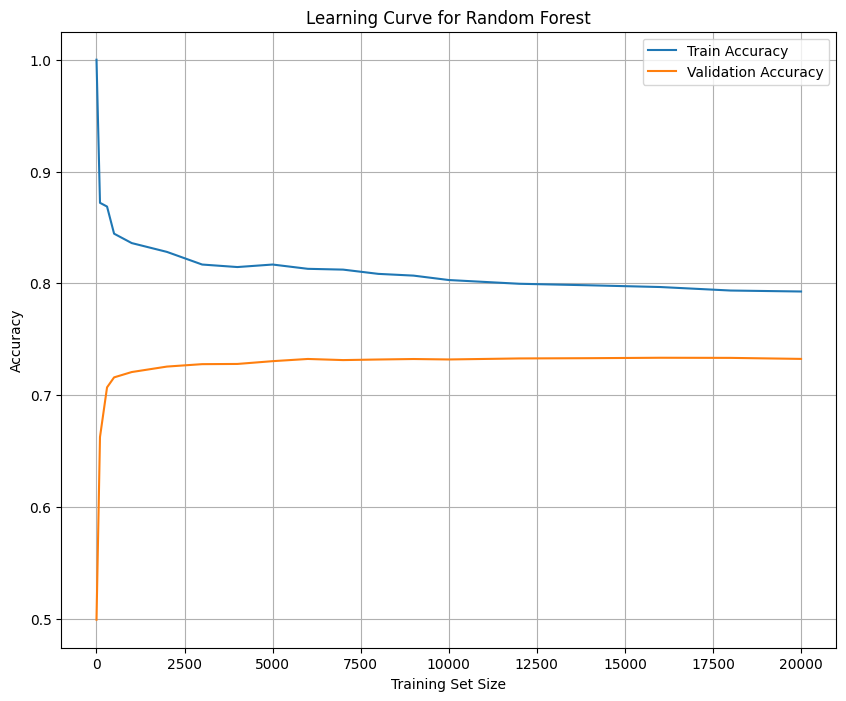

In [44]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=rf,
    X=X_train_df,
    y=y_train,
    cv=5,
    scoring="accuracy",
     train_sizes=[1, 100, 300, 500, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 12000, 14000, 16000, 18000, 20000]


)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.subplots(figsize=(10, 8))
plt.plot(train_sizes, train_mean, label="Train Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")

plt.title("Learning Curve for Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()


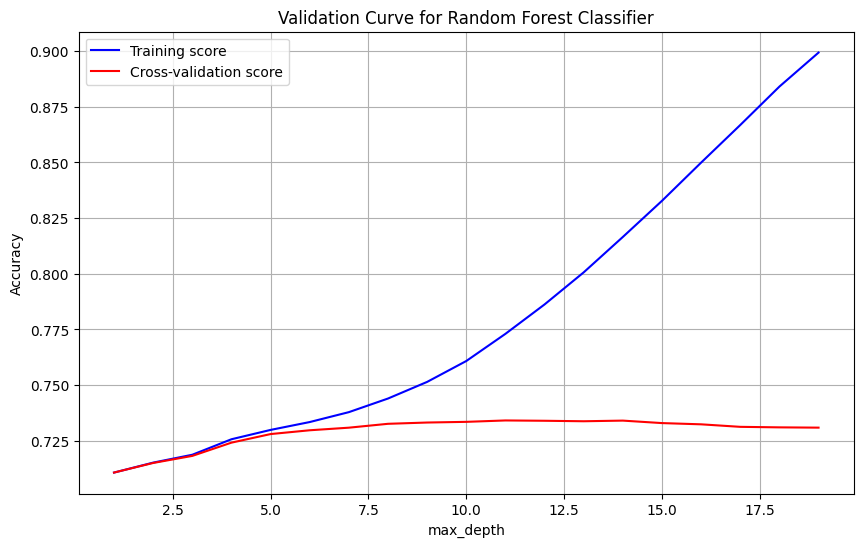

In [45]:
from sklearn.model_selection import validation_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

def plot_validation_curve(estimator, title, X, y, param_name, param_range, cv=5, scoring="accuracy"):
    train_scores, test_scores = validation_curve(
        estimator=estimator,
        X=X,
        y=y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=scoring
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(param_range, train_mean, label="Training score", color="blue")
    plt.plot(param_range, test_mean, label="Cross-validation score", color="red")

    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

random_forest = RandomForestClassifier(random_state=42)

param_range = np.arange(1, 20)

plot_validation_curve(
    random_forest,
    "Validation Curve for Random Forest Classifier",
    X_train_df,
    y_train,
    param_name="max_depth",
    param_range=param_range
)


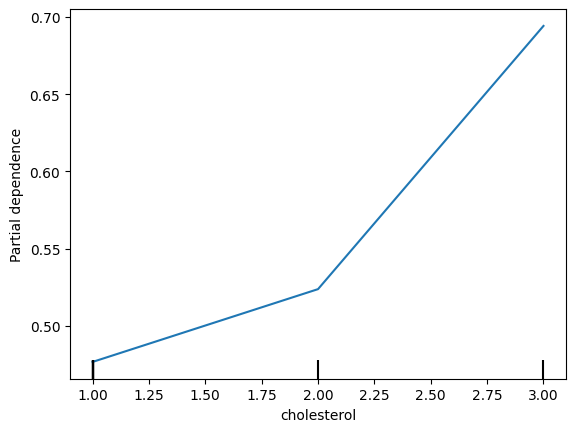

In [46]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt


PartialDependenceDisplay.from_estimator(
    rf,
    X_test_df,
    features=["cholesterol"],
    target=1
)
plt.show()

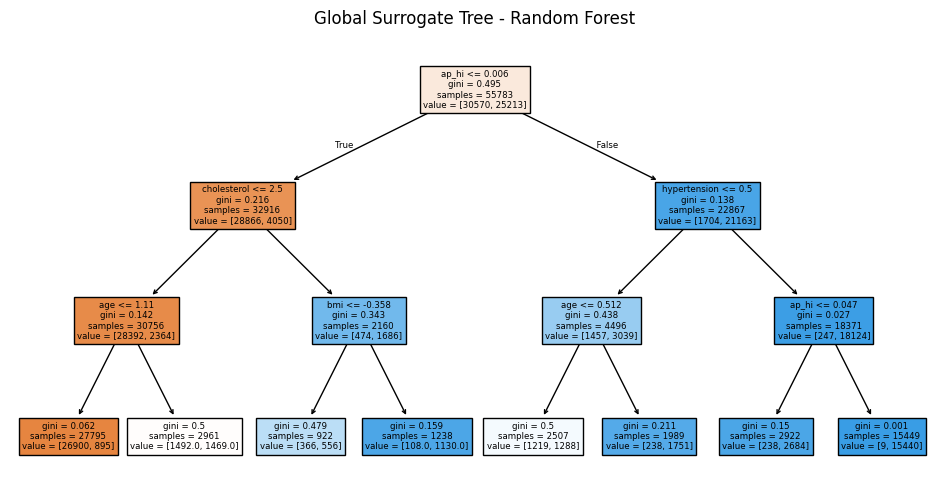

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score

surrogate = DecisionTreeClassifier(max_depth=3)
rf_preds = rf.predict(X_train_df)
surrogate.fit(X_train_df, rf_preds)

from sklearn import tree
plt.figure(figsize=(12,6))
tree.plot_tree(surrogate, feature_names=X_train_df.columns, filled=True)
plt.title("Global Surrogate Tree - Random Forest")
plt.show()


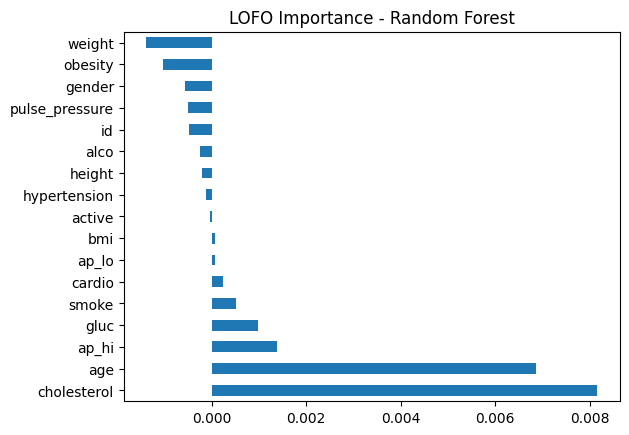

In [52]:
from sklearn.model_selection import cross_val_score

baseline = cross_val_score(rf, X_train_df, y_train, cv=5).mean()

lofo_scores = {}
for col in X_train_df.columns:
    X_lofo = X_train_df.drop(columns=[col])
    score = cross_val_score(rf, X_lofo, y_train, cv=5).mean()
    lofo_scores[col] = baseline - score

lofo_df = pd.Series(lofo_scores).sort_values(ascending=False)
lofo_df.plot(kind='barh')
plt.title("LOFO Importance - Random Forest")
plt.show()

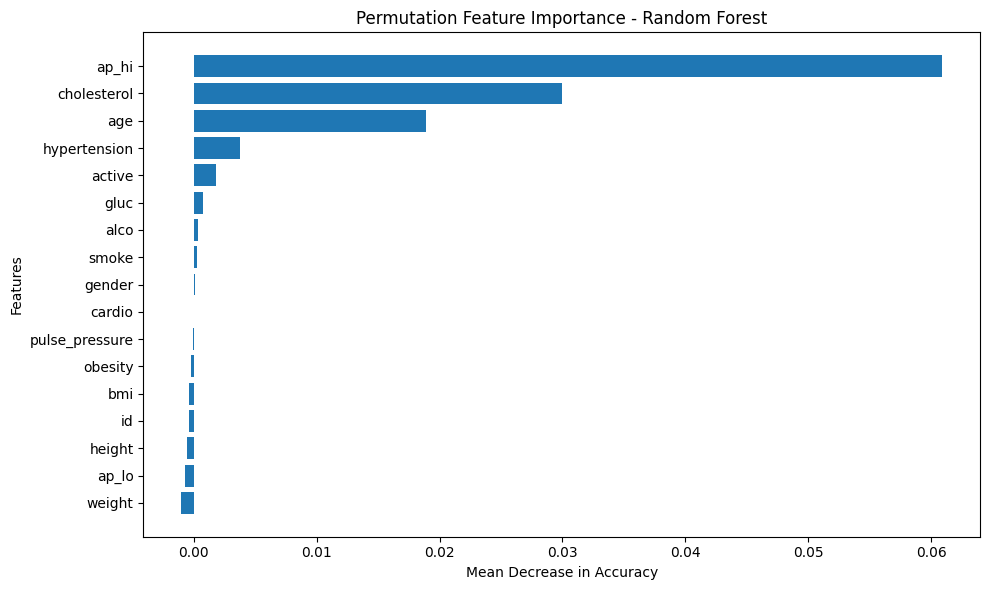

In [54]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

result = permutation_importance(
    rf,
    X_test_df,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy',
    n_jobs=-1
)

sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(np.array(X_test_df.columns)[sorted_idx], result.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance - Random Forest")
plt.xlabel("Mean Decrease in Accuracy")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
